# Limpieza de datos 
Realizado por : Rolando Ortiz Herbas

#  Cargar librerias de trabajo

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import numpy as np
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector

# Cargar el dataset de trabajo

In [ ]:
ruta = "C:/Users/Roland/Documents/UNAD_MEXICO_Matematicas_2022/Semestre_2024_1/ZZZ_Word_y_PT/DatosClientes/Clientes_Dos_Mil.csv"
datasetT = pd.read_csv(ruta)

# Muestra el dataset cargado

In [ ]:
print(datasetT.shape)
datasetT.head()

#4 Eliminar columnas que contienen un solo valor

In [ ]:
datasetT = datasetT.drop('FechaDEfiniquito', axis=1)
datasetT = datasetT.drop('Plazo', axis = 1)
datasetT = datasetT.drop('Nocliente', axis = 1)
datasetT = datasetT.drop('Y', axis = 1)

# Muestra el dataset con las columnas eliminadas

# Ver las variables categóricas , despues de eliminar las columnas que no nos interesan.
# Con data.info() podemos ver las variables categóricas
# (Dtype=object)

In [ ]:
# datasetT['Ingresos']= datasetT['Ingresos'].astype(int)
datasetT['Ingresos'] = pd.to_numeric(datasetT['Ingresos'], errors='coerce').fillna(0).astype('int64')
datasetT['Ingresos'] = np.where((datasetT['Ingresos'] <= 3500)| (datasetT['Ingresos'].isnull()), 3500 * 4, datasetT['Ingresos'])
datasetT.info()

# Identificar valores faltantes

In [ ]:
# Identificar valores faltantes
display(datasetT.isnull().sum())

# Si hay valores faltantes, aplicar estrategias de completar valores o eliminación

# En este caso y con la información de la tabla anterior del dataset vemos que las columnas
# 'Legal' y 'AdjudicaReal' tienen menos información por lo que la completaremos de
# acuerdo con reglas de negocio de la empresa.

In [ ]:

datasetT['Ingresos'] = np.where((datasetT['Ingresos'] == 0) | (datasetT['Ingresos'].isnull()), 
datasetT['Mensualidad'] * 4, datasetT['Ingresos'])


datasetT['Legal'] = np.where((datasetT['Legal'] == 'NA') | (datasetT['Legal'].isnull()), 'Normal', 
datasetT ['Legal'])


datasetT['AdjudicaReal'] = np.where((datasetT['AdjudicaReal'] == 'NA') | (datasetT['AdjudicaReal'].isnull()), 'Normal', datasetT['AdjudicaReal'])

In [ ]:
display(datasetT.isnull().sum())

# Limpieza de valores fuera de rango (outliers)
# La columna Mensualidad, la cual tiene un valor mínimo 
# de 11 pesos. Por lo tanto, estos valores se incrementarán a 2,000 pesos. 
# Además, la columna EdadActual presenta un valor mínimo de 10 años. 
# Por ello, todos los valores menores de 18 años se ajustarán a 18 años.
# Visualizaremos graficamente las variables

In [ ]:
datasetT['Mensualidad'] = np.where((datasetT['Mensualidad'] <= 1999) | (datasetT['Mensualidad'].isnull()), 2000, datasetT['Mensualidad'])

datasetT['EdadActual'] = np.where((datasetT['EdadActual'] <= 18) | (datasetT['EdadActual'].isnull()), 18, datasetT['EdadActual'])
# Para la columna Legal
datasetT['Legal'] = np.where((datasetT['Legal'] == 'NA') | (datasetT['Legal'].isnull()), 'Normal', datasetT['Legal'])

# Para la columna AdjudicaReal
datasetT['AdjudicaReal'] = np.where((datasetT['AdjudicaReal'] == 'NA') | (datasetT['AdjudicaReal'].isnull()), 'Normal', datasetT['AdjudicaReal'])

# Determinar estadística básica del dataset
# Promedio (mean)
# Desviación estandard (std)
# Valor mínimo
# Valor máximo
# Cuartiles (25%, 50% y 75%)

In [ ]:
descripcion = datasetT.describe()

descripcion_formateada = descripcion.applymap(lambda x: f"{x:10.2f}")

print(descripcion_formateada)

In [ ]:
cols_nombres = ['NoPago', 'TotalMonto', 'MontoVencido', 'Mensualidad', 'Ingresos',
           'EdadActual', 'CostoAdmin', 'SemanasAdjud', 'Pagos9', 'Domicilia_Pago',
            'Email', 'timetotV']

In [ ]:
fig, ax = plt.subplots(nrows=12, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace=0.5)
print(enumerate(cols_nombres))
for i, col in enumerate(cols_nombres):
    sns.boxplot(x=col, data=datasetT, ax=ax[i], color="cyan")
    ax[i].set_title(col)

In [ ]:
filtradoNoconfiables = datasetT.loc[datasetT["Y"] == 0]

In [ ]:
descripcion = datasetT.describe()

descripcion_formateada = descripcion.applymap(lambda x: f"{x:10.2f}")

print(descripcion_formateada)

# Corregir tipografia y todo a minusculas

In [ ]:
cols_categoricos = ['Ocupacion', 'EstadoContrato', 'Producto', 'Legal', 'AZULEstatus',
           'AdjudicaReal', 'Genero', 'PersonaTipo', 'dtEstadoContrato', 'GrupoOrigenVenta']

In [ ]:
cols_categoricos = ['Ocupacion']

# convertir tipografia a minisculas 

In [ ]:
for column in datasetT.columns:
    # Representar en minúsculas sólo si la columna es categórica
    if column in cols_categoricos:
        datasetT[column] = datasetT[column].str.lower()

# Análisis de columnas categóricas

In [ ]:
for col in cols_categoricos:
  print(f'Columna {col}: {datasetT[col].nunique()//10} subniveles')
  datasetT[col].describe()

In [ ]:
print(datasetT[col].value_counts()[:10])

In [ ]:
datasetT[col].value_counts().index[:10]


In [ ]:
print(cols_categoricos)

C:\Users\Roland\AppData\Local\Temp\ipykernel_4316\2384546038.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datasetT, y=col, order=orden_categorias, palette='magma')


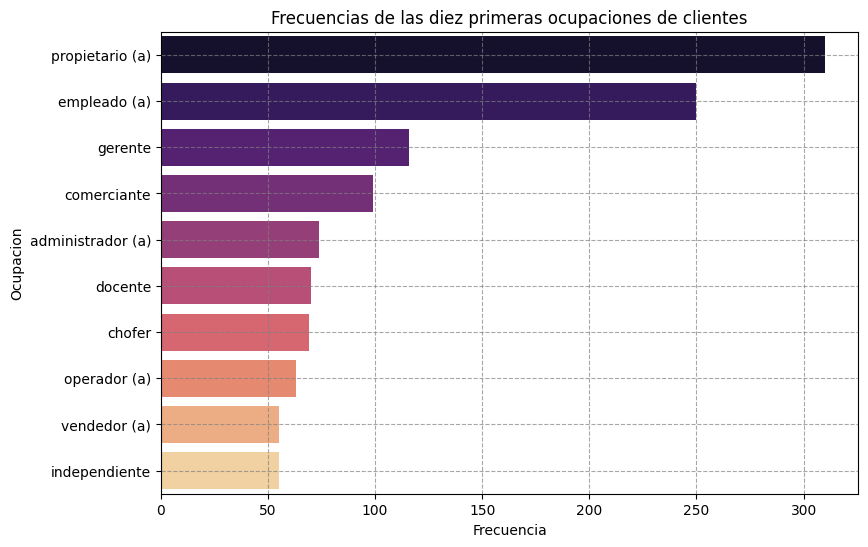

In [62]:
for col in cols_categoricos:
    
    if col == 'Ocupación':
        orden_categorias = (datasetT[col].value_counts().index[0:10])
    else:
        orden_categorias = datasetT[col].value_counts().index[0:10]
    # orden_categorias = datasetT[col].value_counts().index

    # Ajustar el tamaño de la figura
    if col == 'Ocupación':
        plt.figure(figsize=(9, 15))
    else:
        plt.figure(figsize=(9, 6))

    # Crear la gráfica de conteo en orden descendente
    
    sns.countplot(data=datasetT, y=col, order=orden_categorias, palette='magma')

    # Títulos y etiquetas
    #plt.title("Fercuencia " + col +" (ordenado)")
    plt.title("Frecuencias de las diez primeras ocupaciones de clientes")
    plt.xlabel("Frecuencia")
    # plt.ylabel("Categorías")
    plt.ylabel(col)
    plt.grid(True, which='both', axis='both', linestyle='--', color='gray', alpha=0.7)

    # Mostrar la gráfica
    plt.show()

# Clasificación y conteo de Clientes No confiables por Genero , Ocupación y GrupoOrigenVentas 

In [ ]:

filtradoNoconfiables = datasetT.loc[datasetT["Y"] == 0]
#filtradoNoconfiables['Y']



In [ ]:

filtrado = filtradoNoconfiables.query('Y < 1')
# filtrado
filtrado.groupby('Genero')[['Y']].count()

In [ ]:
filtrado.groupby('Ocupacion')[['Y']].count()


In [ ]:
filtrado.groupby('GrupoOrigenVenta')[['Y']].count()

# Clasificación y conteo de Clientes confiables por Genero , Ocupación y GrupoOrigenVentas 

In [ ]:
filtradoConfiables = datasetT.loc[datasetT["Y"] == 1]
filtrado = filtradoConfiables.query('Y == 1')
# filtrado
filtrado.groupby('Genero')[['Y']].count()

#  

In [ ]:
filtrado.groupby('Ocupacion')[['Y']].count()

In [ ]:
filtrado.groupby('GrupoOrigenVenta')[['Y']].count()

# Correlaciones entre variables numéricas

In [ ]:

matriz_correlacion = datasetT.corr()
# Crear un mapa de calor con valores numéricos en cada cuadro
plt.figure(figsize=(10, 8))  # Ajusta el tamaño de la figura según tus necesidades
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación")
plt.show()

# Guardar el dataset limpio en un archivo CSV

In [ ]:
datasetT.to_csv('C:/Users/Roland/Documents/UNAD_MEXICO_Matematicas_2022/Semestre_2024_1/ZZZ_Word_y_PT/DatosClientes/Clientes_Dos_Mil_limpio.csv', index=False, quoting=csv.QUOTE_NONNUMERIC)